<a href="https://colab.research.google.com/github/Tiffanyxxx3238/CPE-practice/blob/main/Success.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 設置Colab環境

In [ ]:
# 安裝必要的庫
!pip install ultralytics  # YOLOv8
!pip install segment-anything-medical  # SAM-Med2D
!pip install torch torchvision
!pip install opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

## 實現SAM-Med2D分割


In [ ]:
# 克隆 SAM-Med2D 倉庫
!git clone https://github.com/OpenGVLab/SAM-Med2D.git

fatal: destination path 'SAM-Med2D' already exists and is not an empty directory.


In [ ]:
# 克隆原始 SAM 倉庫
!git clone https://github.com/facebookresearch/segment-anything.git
!cd segment-anything && pip install -e .

# 下載預訓練模型
!wget -P segment-anything/checkpoints https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

fatal: destination path 'segment-anything' already exists and is not an empty directory.
Obtaining file:///content/segment-anything
  Preparing metadata (setup.py) ... done
  Attempting uninstall: segment_anything
    Found existing installation: segment_anything 1.0
    Uninstalling segment_anything-1.0:
      Successfully uninstalled segment_anything-1.0
  Running setup.py develop for segment_anything
--2025-04-25 13:21:23--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.158.24, 3.163.158.86, 3.163.158.21, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.158.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘segment-anything/checkpoints/sam_vit_b_01ec64.pth.3’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   161MB/s    in 2.2s    

2025-04-25 13:21:26 (161 MB/s) - ‘segment-anything/checkp

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-v97d92sl
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-v97d92sl
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=f98b33c02b43a3cf9d322528a79934fa968dda6a79f39a2c9e696d2d2a1dda21
  Stored in directory: /tmp/pip-ephem-wheel-cache-rkm7bces/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything
  Attempting uninstall: segment_anything
    Found existing installation: segment_anything 1.0
    Uninstalling segment_anything-1.0:
      Successfully uninstalled segment_anything-1.0
--2025-04-25 13:21:41--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01e

Saving 67xtkc67cawe12.webp to 67xtkc67cawe12.webp


<ipython-input-4-9f53c2a66f41>:76: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-4-9f53c2a66f41>:76: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-4-9f53c2a66f41>:76: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-4-9f53c2a66f41>:76: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-4-9f53c2a66f41>:76: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-4-9f53c2a66f41>:76: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-4-9f53c2a66f41>:76: UserWarning: Glyph 25513 (\N{CJK UNIFIED IDEOGRAPH-63A9}) missing from font(s

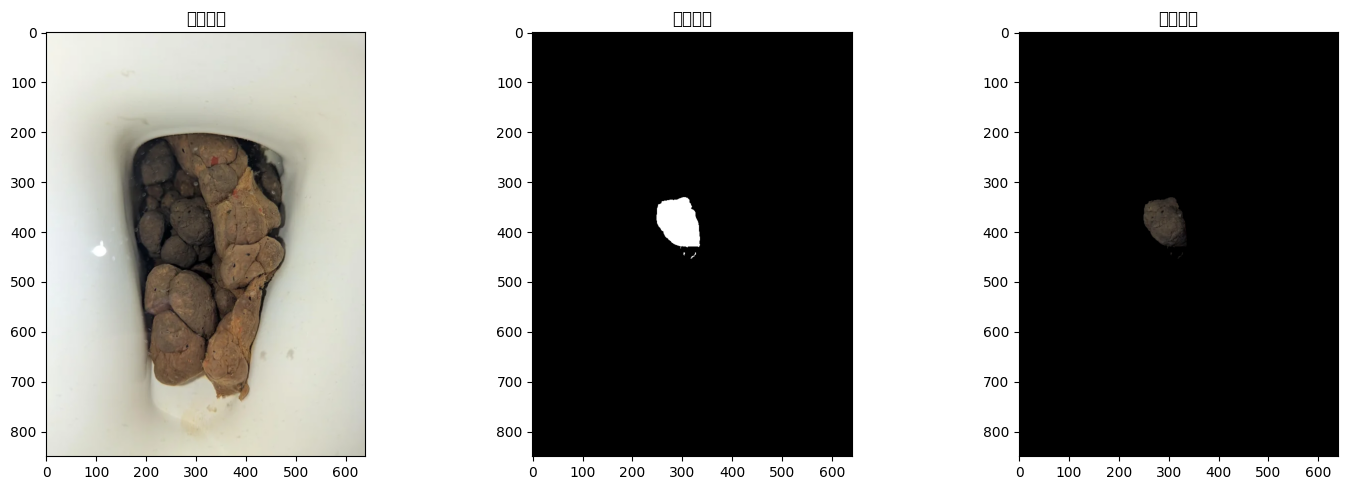

分割結果已保存至 segmented_67xtkc67cawe12.webp


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
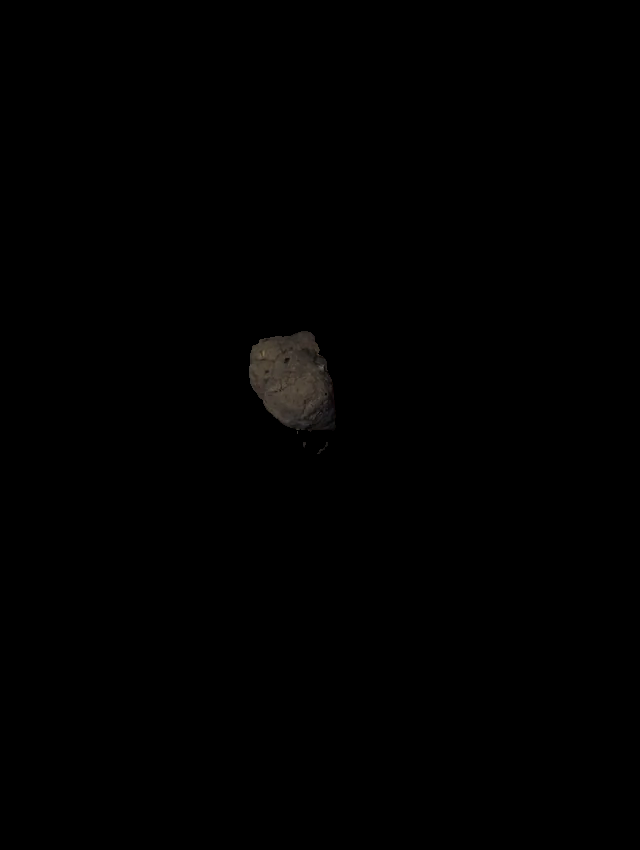

In [ ]:
# 導入所需庫
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 安裝 segment-anything
!pip install git+https://github.com/facebookresearch/segment-anything.git

# 下載預訓練模型
!mkdir -p sam_checkpoints
!wget -P sam_checkpoints https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# 正確導入 SAM
from segment_anything import sam_model_registry, SamPredictor

# 設置設備
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

# 正確初始化 SAM
sam_checkpoint = "./sam_checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

# 分割函數
def segment_stool(image_path):
    """使用 SAM 分割圖像中的大便區域"""
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    predictor.set_image(image)

    h, w, _ = image.shape
    input_point = np.array([[w//2, h//2]])
    input_label = np.array([1])  # 1表示前景

    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True,
    )

    best_mask_idx = np.argmax(scores)
    best_mask = masks[best_mask_idx]

    segmented_image = np.zeros_like(image)
    segmented_image[best_mask] = image[best_mask]

    return segmented_image, best_mask

# 上傳+分割函數
def upload_and_segment():
    uploaded = files.upload()

    for filename in uploaded.keys():
        image_path = filename
        segmented_img, mask = segment_stool(image_path)

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
        plt.title('原始圖像')

        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap='gray')
        plt.title('分割掩碼')

        plt.subplot(1, 3, 3)
        plt.imshow(segmented_img)
        plt.title('分割結果')

        plt.tight_layout()
        plt.show()

        output_path = f"segmented_{filename}"
        cv2.imwrite(output_path, cv2.cvtColor(segmented_img, cv2.COLOR_RGB2BGR))
        print(f"分割結果已保存至 {output_path}")

        return segmented_img

# 執行
upload_and_segment()


In [ ]:
# 處理Normal類別的
import os
os.makedirs("/content/input_images_Normal", exist_ok=True)

from google.colab import files
uploaded = files.upload()

# 把上傳的圖片移到 input_images 資料夾
for filename in uploaded.keys():
    os.rename(filename, f"/content/input_images_Normal/{filename}")
print("✅ 圖片已上傳並移動到 /content/input_images_Normal/")

Saving 09_jpg.rf.d91e02d74a11967c8c9fd148b623840d.jpg to 09_jpg.rf.d91e02d74a11967c8c9fd148b623840d (1).jpg
Saving 142_jpeg.rf.965c606e155138d0a36145ec4d859686.jpg to 142_jpeg.rf.965c606e155138d0a36145ec4d859686.jpg
Saving 143_jpeg.rf.dbb5d1d36b7631af1b4bb281fdc1c313.jpg to 143_jpeg.rf.dbb5d1d36b7631af1b4bb281fdc1c313.jpg
Saving 149_jpeg.rf.57fb954bf2ebee080efed9fe74c19c99.jpg to 149_jpeg.rf.57fb954bf2ebee080efed9fe74c19c99.jpg
Saving 150_jpeg.rf.60b8400cf66101640d7ad4641c3dcb93.jpg to 150_jpeg.rf.60b8400cf66101640d7ad4641c3dcb93.jpg
Saving 152_jpeg.rf.28fcd79dca758eaeeb2b43c8f92edc62.jpg to 152_jpeg.rf.28fcd79dca758eaeeb2b43c8f92edc62.jpg
Saving 153_jpeg.rf.73d4e4010e1ac54a2e1190c6cef106ea.jpg to 153_jpeg.rf.73d4e4010e1ac54a2e1190c6cef106ea.jpg
Saving 155_jpeg.rf.20fc92dd927fb7a96dbe6454082a3e63.jpg to 155_jpeg.rf.20fc92dd927fb7a96dbe6454082a3e63.jpg
Saving 157_jpeg.rf.c720c5fa749d5a7ac628a992220ecd46.jpg to 157_jpeg.rf.c720c5fa749d5a7ac628a992220ecd46.jpg
Saving 158_jpeg.rf.bac614854

In [ ]:
# 📦 導入必要套件
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# 安裝 segment-anything（只需第一次）
!pip install git+https://github.com/facebookresearch/segment-anything.git -q

# 下載 SAM 模型（只需第一次）
!mkdir -p sam_checkpoints
!wget -q -P sam_checkpoints https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# 匯入 SAM 模組
from segment_anything import sam_model_registry, SamPredictor

# 設定設備
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

# 初始化 SAM 模型
sam_checkpoint = "./sam_checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)
predictor = SamPredictor(sam)

# 🧠 多點提示的分割函數（強化版）
def segment_stool(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)

    h, w = image.shape[:2]

    # 🔍 灰階 + 閾值化，找潛在便便區域
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    input_points = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > (h * w * 0.005):  # 太小的忽略
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                input_points.append([cx, cy])

    # 若無偵測到輪廓，退而求其次用中心點
    if not input_points:
        print("⚠️ 沒有找到明確區域，使用圖中心備案")
        input_points = [[w // 2, h // 2]]

    input_points = np.array(input_points)
    input_labels = np.ones(len(input_points))

    # SAM 預測
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=False,
    )

    # 🧩 合併所有遮罩
    combined_mask = np.any(masks, axis=0).astype(np.uint8)

    # 🧼 遮罩清理
    kernel = np.ones((5, 5), np.uint8)
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)

    # 🧮 評估遮罩品質
    area = np.sum(combined_mask)
    total = combined_mask.shape[0] * combined_mask.shape[1]
    quality = "good" if total * 0.01 < area < total * 0.9 else "low"

    # 🖼️ 套用遮罩產生結果圖
    segmented_image = np.zeros_like(image_rgb)
    segmented_image[combined_mask.astype(bool)] = image_rgb[combined_mask.astype(bool)]

    return segmented_image, combined_mask, quality

# 🔄 批次分割 + 分類儲存
def batch_segment_folder(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)
    image_files = [f for f in os.listdir(input_folder)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]

    print(f"🔍 共偵測到 {len(image_files)} 張圖片，開始處理...")

    for filename in tqdm(image_files):
        input_path = os.path.join(input_folder, filename)

        try:
            segmented_img, mask, quality = segment_stool(input_path)
            orig_image = cv2.cvtColor(cv2.imread(input_path), cv2.COLOR_BGR2RGB)

            # 📁 根據品質儲存至對應資料夾
            save_dir = output_folder if quality == "good" else os.path.join(output_folder, "low_quality")
            os.makedirs(save_dir, exist_ok=True)
            output_path = os.path.join(save_dir, filename)
            cv2.imwrite(output_path, cv2.cvtColor(segmented_img, cv2.COLOR_RGB2BGR))

            # 📊 顯示圖像組合
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(orig_image)
            plt.title(f"原圖：{filename}")

            plt.subplot(1, 3, 2)
            plt.imshow(mask, cmap="gray")
            plt.title(f"遮罩（{quality}）")

            plt.subplot(1, 3, 3)
            plt.imshow(segmented_img)
            plt.title("分割結果")
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"❌ 處理 {filename} 發生錯誤：{e}")

    print(f"✅ 完成！結果儲存在：{output_folder}")

# ✨ 執行
input_folder = "/content/input_images"              # 上傳圖片資料夾
output_folder = "/content/renew_dataset/Normal"       # 儲存結果資料夾

batch_segment_folder(input_folder, output_folder)


(單用 SAM + 提示點:發現遮罩誤判超多，不知道哪裡是便便（只是抓一個前景）)

In [ ]:
# 處理Constipated類別的

import os
os.makedirs("/content/input_images_Costipated", exist_ok=True)

from google.colab import files
uploaded = files.upload()

# 把上傳的圖片移到 input_images 資料夾
for filename in uploaded.keys():
    os.rename(filename, f"/content/input_images_Costipated/{filename}")
print("✅ 圖片已上傳並移動到 /content/input_images_Costipated/")


Saving blood-in-poop-what-is-this-v0-p81ixvc94bue1.webp to blood-in-poop-what-is-this-v0-p81ixvc94bue1 (1).webp
Saving ive-been-doing-these-turds-that-seem-tornado-potatoes-v0-is5sq8trbtve1.webp to ive-been-doing-these-turds-that-seem-tornado-potatoes-v0-is5sq8trbtve1.webp
Saving pale-poop-help-v0-glmjcx4monue1.webp to pale-poop-help-v0-glmjcx4monue1.webp
Saving boulders-in-a-golden-lake-v0-l7lv9db5p4ve1.webp to boulders-in-a-golden-lake-v0-l7lv9db5p4ve1.webp
Saving 67xtkc67cawe12.webp to 67xtkc67cawe12 (1).webp
Saving poop-at-work-in-france-v0-cfbi1dtplcwe1.webp to poop-at-work-in-france-v0-cfbi1dtplcwe1.webp
Saving 099_jpg.rf.41bda3b64cde915617544360c5f665c5.jpg to 099_jpg.rf.41bda3b64cde915617544360c5f665c5.jpg
Saving 138_jpeg.rf.2a7e1e89ff3a1f075782741ccaf30ac2.jpg to 138_jpeg.rf.2a7e1e89ff3a1f075782741ccaf30ac2.jpg
Saving 147_jpeg.rf.0fb8b8220c32cd08e9d1c848fa75422a.jpg to 147_jpeg.rf.0fb8b8220c32cd08e9d1c848fa75422a.jpg
Saving 154_jpeg.rf.1835e419b0a7e29699f17d086a99a594.jpg to 1

In [ ]:
# 導入所需庫
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import files

# 安裝 segment-anything
!pip install git+https://github.com/facebookresearch/segment-anything.git

# 下載預訓練模型
!mkdir -p sam_checkpoints
!wget -P sam_checkpoints https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# 匯入 SAM 模型模組
from segment_anything import sam_model_registry, SamPredictor

# 設定裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

# 初始化 SAM 模型
sam_checkpoint = "./sam_checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)
predictor = SamPredictor(sam)

# 分割函數（自動多點提示）
def segment_stool(image_path):
    """改進版：使用SAM-Med2D + 最大輪廓提示 + 遮罩清理 + 面積篩選"""
    import cv2
    import numpy as np

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)

    # 預設中心點提示
    h, w = image.shape[:2]
    fallback_point = np.array([[w // 2, h // 2]])
    input_label = np.array([1])

    # 初步用中心點提示
    masks, scores, _ = predictor.predict(
        point_coords=fallback_point,
        point_labels=input_label,
        multimask_output=True,
    )

    best_mask = masks[np.argmax(scores)].astype(np.uint8)

    # 🔍 嘗試找出最大區域輪廓中心作為更精確提示點
    contours, _ = cv2.findContours(best_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        M = cv2.moments(largest)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            better_point = np.array([[cx, cy]])

            # 🔁 再次分割使用更準確提示點
            masks, scores, _ = predictor.predict(
                point_coords=better_point,
                point_labels=input_label,
                multimask_output=True,
            )
            best_mask = masks[np.argmax(scores)].astype(np.uint8)

    # 🧼 遮罩開運算清理雜訊
    kernel = np.ones((5, 5), np.uint8)
    best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_OPEN, kernel)

    # 🧮 遮罩面積篩選（過小或過大代表失敗）
    area = np.sum(best_mask)
    total = best_mask.shape[0] * best_mask.shape[1]
    if area < total * 0.01 or area > total * 0.9:
        print("⚠️ 遮罩面積異常，跳過此圖")
        return None, None

    # 🖼️ 產生遮罩後的分割圖
    segmented_image = np.zeros_like(image_rgb)
    segmented_image[best_mask.astype(bool)] = image_rgb[best_mask.astype(bool)]

    return segmented_image, best_mask

# 批次處理資料夾圖片
def batch_segment_folder(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)
    image_files = [f for f in os.listdir(input_folder)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]

    print(f"🔍 共偵測到 {len(image_files)} 張圖片，開始分割處理...")

    for filename in tqdm(image_files):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        try:
            segmented_img, best_mask, orig_image = segment_stool(input_path)

            # 儲存分割結果圖
            cv2.imwrite(output_path, cv2.cvtColor(segmented_img, cv2.COLOR_RGB2BGR))

            # 顯示原圖 / 遮罩 / 分割結果
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(orig_image)
            plt.title(f"原圖：{filename}")

            plt.subplot(1, 3, 2)
            plt.imshow(best_mask, cmap="gray")
            plt.title("分割遮罩")

            plt.subplot(1, 3, 3)
            plt.imshow(segmented_img)
            plt.title("分割結果")

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"❌ 處理 {filename} 時發生錯誤：{e}")

    print(f"✅ 所有圖片已處理完畢，儲存在：{output_folder}")

# 📁 設定資料夾路徑並執行批次分割
input_folder = "/content/input_images_Costipated"        # 請確認這個資料夾存在且有圖片
output_folder = "/content/new_dataset/Constipated"     # 分割後存放位置

batch_segment_folder(input_folder, output_folder)


In [ ]:
# 處理Loose類別的

import os
os.makedirs("/content/input_images_Loose", exist_ok=True)

from google.colab import files
uploaded = files.upload()

# 把上傳的圖片移到 input_images 資料夾
for filename in uploaded.keys():
    os.rename(filename, f"/content/input_images_Loose/{filename}")
print("✅ 圖片已上傳並移動到 /content/input_images_Loose/")

Saving 036_jpg.rf.3c4a9344778bcd6d1f007540ec868935.jpg to 036_jpg.rf.3c4a9344778bcd6d1f007540ec868935.jpg
Saving 041_jpg.rf.c37c50fc400e16802a0fe0309c465aec.jpg to 041_jpg.rf.c37c50fc400e16802a0fe0309c465aec.jpg
Saving 043_jpg.rf.153740998ca8bc2bcdb7054e39ac3ddb.jpg to 043_jpg.rf.153740998ca8bc2bcdb7054e39ac3ddb.jpg
Saving 044_jpg.rf.c36bd2a5ba6a8b0e1454e55b3c889c9d.jpg to 044_jpg.rf.c36bd2a5ba6a8b0e1454e55b3c889c9d.jpg
Saving 045_jpg.rf.6cd261457321209f70fe605b5e518118.jpg to 045_jpg.rf.6cd261457321209f70fe605b5e518118.jpg
Saving 046_jpg.rf.78aa965799c614040d9f6a0e4570fc0d.jpg to 046_jpg.rf.78aa965799c614040d9f6a0e4570fc0d.jpg
Saving 047_jpg.rf.f75e605d7871294114707c63a43cd67a.jpg to 047_jpg.rf.f75e605d7871294114707c63a43cd67a.jpg
Saving 048_jpg.rf.0c5cbefab9a563c830f0d29708ae55ad.jpg to 048_jpg.rf.0c5cbefab9a563c830f0d29708ae55ad.jpg
Saving 049_jpg.rf.0e523482c3f245f51d1511537d63b73d.jpg to 049_jpg.rf.0e523482c3f245f51d1511537d63b73d.jpg
Saving 050_jpg.rf.97a30b059109e02c5e2ecc787da9

In [ ]:
# 導入所需庫
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import files

# 安裝 segment-anything
!pip install git+https://github.com/facebookresearch/segment-anything.git

# 下載預訓練模型
!mkdir -p sam_checkpoints
!wget -P sam_checkpoints https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# 匯入 SAM 模型模組
from segment_anything import sam_model_registry, SamPredictor

# 設定裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

# 初始化 SAM 模型
sam_checkpoint = "./sam_checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)
predictor = SamPredictor(sam)

# 分割函數（自動多點提示）
def segment_stool(image_path):
    """改進版：使用SAM-Med2D + 最大輪廓提示 + 遮罩清理 + 面積篩選"""
    import cv2
    import numpy as np

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)

    # 預設中心點提示
    h, w = image.shape[:2]
    fallback_point = np.array([[w // 2, h // 2]])
    input_label = np.array([1])

    # 初步用中心點提示
    masks, scores, _ = predictor.predict(
        point_coords=fallback_point,
        point_labels=input_label,
        multimask_output=True,
    )

    best_mask = masks[np.argmax(scores)].astype(np.uint8)

    # 🔍 嘗試找出最大區域輪廓中心作為更精確提示點
    contours, _ = cv2.findContours(best_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        M = cv2.moments(largest)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            better_point = np.array([[cx, cy]])

            # 🔁 再次分割使用更準確提示點
            masks, scores, _ = predictor.predict(
                point_coords=better_point,
                point_labels=input_label,
                multimask_output=True,
            )
            best_mask = masks[np.argmax(scores)].astype(np.uint8)

    # 🧼 遮罩開運算清理雜訊
    kernel = np.ones((5, 5), np.uint8)
    best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_OPEN, kernel)

    # 🧮 遮罩面積篩選（過小或過大代表失敗）
    area = np.sum(best_mask)
    total = best_mask.shape[0] * best_mask.shape[1]
    if area < total * 0.01 or area > total * 0.9:
        print("⚠️ 遮罩面積異常，跳過此圖")
        return None, None

    # 🖼️ 產生遮罩後的分割圖
    segmented_image = np.zeros_like(image_rgb)
    segmented_image[best_mask.astype(bool)] = image_rgb[best_mask.astype(bool)]

    return segmented_image, best_mask


# 批次處理資料夾圖片
def batch_segment_folder(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)
    image_files = [f for f in os.listdir(input_folder)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]

    print(f"🔍 共偵測到 {len(image_files)} 張圖片，開始分割處理...")

    for filename in tqdm(image_files):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        try:
            segmented_img, best_mask, orig_image = segment_stool(input_path)

            # 儲存分割結果圖
            cv2.imwrite(output_path, cv2.cvtColor(segmented_img, cv2.COLOR_RGB2BGR))

            # 顯示原圖 / 遮罩 / 分割結果
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(orig_image)
            plt.title(f"原圖：{filename}")

            plt.subplot(1, 3, 2)
            plt.imshow(best_mask, cmap="gray")
            plt.title("分割遮罩")

            plt.subplot(1, 3, 3)
            plt.imshow(segmented_img)
            plt.title("分割結果")

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"❌ 處理 {filename} 時發生錯誤：{e}")

    print(f"✅ 所有圖片已處理完畢，儲存在：{output_folder}")

# 📁 設定資料夾路徑並執行批次分割
input_folder = "/content/input_images_Loose"        # 請確認這個資料夾存在且有圖片
output_folder = "/content/new_dataset/Loose"     # 分割後存放位置

batch_segment_folder(input_folder, output_folder)


In [ ]:
from ultralytics import YOLO
import os
import numpy as np
import cv2
import torch
from google.colab import drive

# 掛載 Google Drive
drive.mount('/content/drive')

# 建立資料夾結構
def create_dataset_structure():
    base_dir = '/content/drive/MyDrive/stool_classification_dataset'
    for cls in ['constipated', 'normal', 'loose']:
        os.makedirs(f"{base_dir}/train/{cls}", exist_ok=True)
        os.makedirs(f"{base_dir}/val/{cls}", exist_ok=True)

    fine_dir = '/content/drive/MyDrive/stool_fine_classification_dataset'
    fine_classes = {
        'constipated': ['type1', 'type2'],
        'normal': ['type3', 'type4', 'type5'],
        'loose': ['type6', 'type7']
    }
    for main, subs in fine_classes.items():
        for sub in subs:
            os.makedirs(f"{fine_dir}/train/{sub}", exist_ok=True)
            os.makedirs(f"{fine_dir}/val/{sub}", exist_ok=True)
    print("✅ 數據集目錄結構建立完成")

# 粗分類訓練
def train_coarse_classification_model(epochs=50):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"🚀 使用設備: {device}")
    model = YOLO('yolov8n-cls.pt')
    return model.train(
        data='/content/drive/MyDrive/stool_classification_dataset',
        epochs=epochs,
        imgsz=224,
        batch=16,
        project='/content/drive/MyDrive/stool_models',
        name='coarse_classifier'
    )

# 細分類訓練
def train_fine_classification_model(epochs=50):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"🚀 使用設備: {device}")
    model = YOLO('yolov8n-cls.pt')
    return model.train(
        data='/content/drive/MyDrive/stool_fine_classification_dataset',
        epochs=epochs,
        imgsz=224,
        batch=16,
        project='/content/drive/MyDrive/stool_models',
        name='fine_classifier'
    )

# 儲存分割圖像
def save_for_training(segmented_image, class_name, fine_class=None):
    rgb_img = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    coarse_path = f'/content/drive/MyDrive/stool_classification_dataset/train/{class_name}'
    filename = f"{len(os.listdir(coarse_path))}.jpg"
    cv2.imwrite(os.path.join(coarse_path, filename), rgb_img)

    if fine_class:
        fine_path = f'/content/drive/MyDrive/stool_fine_classification_dataset/train/{fine_class}'
        filename = f"{len(os.listdir(fine_path))}.jpg"
        cv2.imwrite(os.path.join(fine_path, filename), rgb_img)

    print(f"📦 已儲存圖片到: {class_name}" + (f" / {fine_class}" if fine_class else ""))

# 預測粗 + 細分類
def predict_stool_type(segmented_image):
    temp_path = "temp_image.jpg"
    cv2.imwrite(temp_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))

    coarse_model = YOLO('/content/drive/MyDrive/stool_models/coarse_classifier/weights/best.pt')
    coarse_result = coarse_model.predict(temp_path, verbose=False)[0]

    # 取得分類結果
    if hasattr(coarse_result, 'probs') and coarse_result.probs is not None:
        coarse_class_id = int(coarse_result.probs.top1)
        coarse_conf = float(coarse_result.probs.top1conf)
        coarse_class = coarse_result.names[coarse_class_id]
    else:
        print("⚠️ 無法取得粗分類結果")
        return None, None, None, None

    print(f"🧠 粗分類結果: {coarse_class}（置信度: {coarse_conf:.2f}）")

    if coarse_conf > 0.9:
        fine_model = YOLO('/content/drive/MyDrive/stool_models/fine_classifier/weights/best.pt')
        fine_result = fine_model.predict(temp_path, verbose=False)[0]

        if hasattr(fine_result, 'probs') and fine_result.probs is not None:
            fine_class_id = int(fine_result.probs.top1)
            fine_conf = float(fine_result.probs.top1conf)
            fine_class = fine_result.names[fine_class_id]
            print(f"🔍 細分類結果: {fine_class}（置信度: {fine_conf:.2f}）")
            return coarse_class, coarse_conf, fine_class, fine_conf

    return coarse_class, coarse_conf, None, None


## 互動式自行標註(但colab不行)

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
from google.colab import files

# 設定設備
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

# 載入 SAM 模型
sam_checkpoint = "./sam_checkpoints/sam_vit_b_01ec64.pth"
model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)
predictor = SamPredictor(sam)

# 點擊位置儲存
clicked_points = []

# 滑鼠事件 callback
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        clicked_points.append([x, y])
        print(f"🟢 點選：({x}, {y})")
        cv2.circle(param, (x, y), 5, (0, 0, 255), -1)  # 在圖上畫紅點
        cv2.imshow("請點選便便區域（按 Enter 完成）", param)

# 主分割流程
def interactive_segment_cv(image_path):
    global clicked_points
    clicked_points = []

    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    clone = image_bgr.copy()
    cv2.imshow("請點選便便區域（按 Enter 完成）", clone)
    cv2.setMouseCallback("請點選便便區域（按 Enter 完成）", click_event, clone)

    print("👉 用滑鼠點選便便區域（左鍵），點完後按 Enter 鍵完成")

    # 等待 Enter 鍵（key code 13）
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == 13:
            break

    cv2.destroyAllWindows()

    if not clicked_points:
        print("⚠️ 沒有點選任何點，分割中止")
        return

    input_points = np.array(clicked_points)
    input_labels = np.ones(len(clicked_points))  # 前景點

    predictor.set_image(image_rgb)

    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]
    segmented_image = np.zeros_like(image_rgb)
    segmented_image[best_mask] = image_rgb[best_mask]

    # 顯示結果
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("原始圖像")

    plt.subplot(1, 3, 2)
    plt.imshow(best_mask, cmap="gray")
    plt.title("分割掩碼")

    plt.subplot(1, 3, 3)
    plt.imshow(segmented_image)
    plt.title("分割結果")

    plt.tight_layout()
    plt.show()

    output_path = f"segmented_{image_path}"
    cv2.imwrite(output_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))
    print(f"✅ 分割結果已儲存：{output_path}")

# 上傳並執行互動式分割
def upload_and_run_interactive_cv():
    uploaded = files.upload()
    for filename in uploaded:
        interactive_segment_cv(filename)

使用設備: cuda


In [ ]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from segment_anything_medical import sam_model_registry, SamPredictor
from google.colab import files

# 下載SAM-Med2D模型
!wget https://huggingface.co/ChaoningZhang/SAM-Med2D/resolve/main/sam_med2d_turbo.pth

# 設置模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sam_checkpoint = "sam_med2d_turbo.pth"
model_type = "vit_b"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

def segment_stool(image_path):
    """使用SAM-Med2D分割圖像中的大便區域"""
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 將圖像輸入到預測器
    predictor.set_image(image)

    # 使用圖像中心作為提示點
    h, w, _ = image.shape
    input_point = np.array([[w//2, h//2]])
    input_label = np.array([1])  # 1表示前景

    # 獲取分割掩碼
    masks, scores, logits = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True,  # 返回多個掩碼
    )

    # 選擇最佳掩碼
    best_mask = masks[np.argmax(scores)]

    # 應用掩碼提取大便區域
    segmented_image = np.zeros_like(image)
    segmented_image[best_mask] = image[best_mask]

    return segmented_image, best_mask

# 測試函數
def upload_and_segment():
    uploaded = files.upload()

    for filename in uploaded.keys():
        image_path = filename
        segmented_img, mask = segment_stool(image_path)

        # 顯示原始圖像和分割結果
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
        plt.title('原始圖像')

        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap='gray')
        plt.title('分割掩碼')

        plt.subplot(1, 3, 3)
        plt.imshow(segmented_img)
        plt.title('分割結果')

        plt.tight_layout()
        plt.show()

        # 保存分割結果
        output_path = f"segmented_{filename}"
        cv2.imwrite(output_path, cv2.cvtColor(segmented_img, cv2.COLOR_RGB2BGR))
        print(f"分割結果已保存至 {output_path}")

        return segmented_img  # 返回分割結果供後續使用

# 執行以上傳和分割圖像
# segmented_image = upload_and_segment()

## 建立YOLOv8分類模型

In [ ]:
from ultralytics import YOLO
import os
import numpy as np
import cv2
from google.colab import drive

# 掛載Google Drive以保存模型和數據
drive.mount('/content/drive')

# 創建數據集目錄結構
def create_dataset_structure():
    base_dir = '/content/drive/MyDrive/stool_classification_dataset'
    os.makedirs(base_dir, exist_ok=True)

    # 創建主分類目錄
    for main_class in ['constipated', 'normal', 'loose']:
        os.makedirs(f"{base_dir}/train/{main_class}", exist_ok=True)
        os.makedirs(f"{base_dir}/val/{main_class}", exist_ok=True)

    # 創建細分類目錄
    fine_classes = {
        'constipated': ['type1', 'type2'],
        'normal': ['type3', 'type4', 'type5'],
        'loose': ['type6', 'type7']
    }

    fine_base_dir = '/content/drive/MyDrive/stool_fine_classification_dataset'
    os.makedirs(fine_base_dir, exist_ok=True)

    for main_class, sub_classes in fine_classes.items():
        for sub_class in sub_classes:
            os.makedirs(f"{fine_base_dir}/train/{sub_class}", exist_ok=True)
            os.makedirs(f"{fine_base_dir}/val/{sub_class}", exist_ok=True)

    print("數據集目錄結構已創建完成")

# 訓練粗分類模型
def train_coarse_classification_model(epochs=50):
    # 使用預訓練的YOLOv8分類模型
    model = YOLO('yolov8n-cls.pt')

    # 訓練模型
    results = model.train(
        data='/content/drive/MyDrive/stool_classification_dataset',
        epochs=epochs,
        imgsz=640,
        batch=16,
        project='/content/drive/MyDrive/stool_models',
        name='coarse_classifier'
    )

    return model

# 訓練細分類模型
def train_fine_classification_model(epochs=50):
    # 使用預訓練的YOLOv8分類模型
    model = YOLO('yolov8n-cls.pt')

    # 訓練模型
    results = model.train(
        data='/content/drive/MyDrive/stool_fine_classification_dataset',
        epochs=epochs,
        imgsz=640,
        batch=16,
        project='/content/drive/MyDrive/stool_models',
        name='fine_classifier'
    )

    return model

# 將分割後的圖像保存到適當的目錄
def save_for_training(segmented_image, class_name, fine_class=None):
    # 為粗分類保存
    coarse_dir = f'/content/drive/MyDrive/stool_classification_dataset/train/{class_name}'
    os.makedirs(coarse_dir, exist_ok=True)
    filename = f"{coarse_dir}/{len(os.listdir(coarse_dir))}.jpg"
    cv2.imwrite(filename, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))

    # 如果提供了細分類，也保存到細分類目錄
    if fine_class:
        fine_dir = f'/content/drive/MyDrive/stool_fine_classification_dataset/train/{fine_class}'
        os.makedirs(fine_dir, exist_ok=True)
        filename = f"{fine_dir}/{len(os.listdir(fine_dir))}.jpg"
        cv2.imwrite(filename, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))

    print(f"圖像已保存用於訓練, 類別: {class_name}" + (f", 細分類: {fine_class}" if fine_class else ""))

# 用於預測的函數
def predict_stool_type(segmented_image):
    # 轉換為BGR並保存臨時文件
    temp_path = "temp_image.jpg"
    cv2.imwrite(temp_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))

    # 加載粗分類模型
    coarse_model = YOLO('/content/drive/MyDrive/stool_models/coarse_classifier/weights/best.pt')

    # 進行粗分類預測
    coarse_results = coarse_model.predict(temp_path)
    coarse_class = coarse_results[0].names[int(coarse_results[0].probs.top1)]
    coarse_conf = float(coarse_results[0].probs.top1conf)

    print(f"粗分類結果: {coarse_class}, 置信度: {coarse_conf:.2f}")

    # 如果粗分類置信度高於閾值，進行細分類
    if coarse_conf > 0.9:
        fine_model = YOLO('/content/drive/MyDrive/stool_models/fine_classifier/weights/best.pt')
        fine_results = fine_model.predict(temp_path)
        fine_class = fine_results[0].names[int(fine_results[0].probs.top1)]
        fine_conf = float(fine_results[0].probs.top1conf)

        print(f"細分類結果: {fine_class}, 置信度: {fine_conf:.2f}")
        return coarse_class, coarse_conf, fine_class, fine_conf
    else:
        return coarse_class, coarse_conf, None, None

# 創建數據集結構
# create_dataset_structure()